In [2]:
#import libraries
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)


In [23]:
skills_count = df.explode('job_skills').groupby(['job_title_short','job_skills']).size().reset_index(name = 'Skill Count').sort_values(by='Skill Count', ascending = False)
skills_count

,job_title_short,job_skills,Skill Count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


Text(0.5, 1.0, 'Top 15 Skills for Data Engineer')

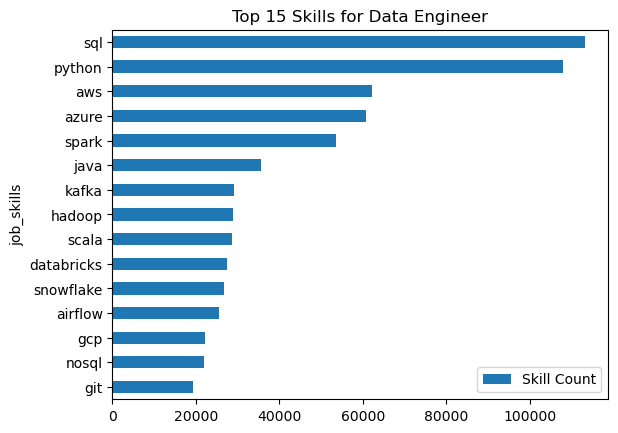

In [40]:
job_title = 'Data Engineer'
top_skills = 15

skills_count[skills_count['job_title_short'] == job_title].head(top_skills).plot(kind = 'barh', x='job_skills', y='Skill Count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}')

Text(0.5, 1.0, 'Top 15 Skills for Data Analyst')

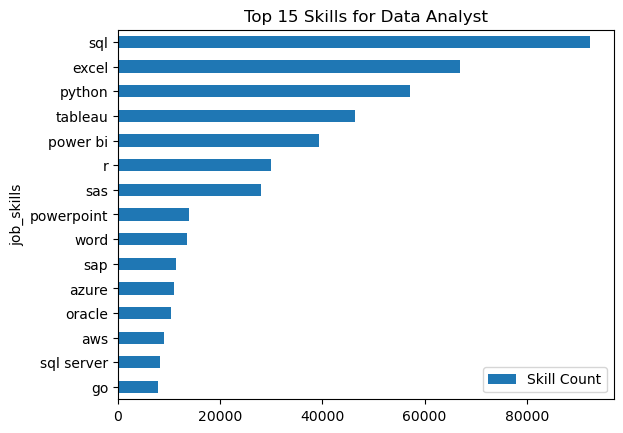

In [41]:
job_title = 'Data Analyst'
top_skills = 15

skills_count[skills_count['job_title_short'] == job_title].head(top_skills).plot(kind = 'barh', x='job_skills', y='Skill Count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} Skills for {job_title}')